In [ ]:
from collections import deque, defaultdict
from itertools import permutations
from functools import lru_cache

# ============================================================
# 0. Affine A~2 via affine permutations (window notation)
# ============================================================

E = (1, 2, 3)
ALL_PERMS = list(permutations((1, 2, 3)))

def lab(k: int) -> int:
    return ((k - 1) % 3) + 1

def right_gen(win, s):
    a, b, c = win
    if s == 1:
        return (b, a, c)
    if s == 2:
        return (a, c, b)
    if s == 3:
        return (c - 3, b, a + 3)
    raise ValueError(f"bad generator {s}")

def apply_word_right(win, word):
    for s in word:
        win = right_gen(win, s)
    return win

def left_gen_value(k, s):
    r = k % 3
    if s == 1:
        if r == 1:
            return k + 1
        if r == 2:
            return k - 1
        return k
    if s == 2:
        if r == 2:
            return k + 1
        if r == 0:
            return k - 1
        return k
    if s == 3:
        if r == 1:
            return k - 1
        if r == 0:
            return k + 1
        return k
    raise ValueError(f"bad generator {s}")

def left_gen(win, s):
    return tuple(left_gen_value(x, s) for x in win)

def length_bfs(max_len):
    length = {E: 0}
    red = {E: ()}
    q = deque([E])

    while q:
        cur = q.popleft()
        L = length[cur]
        if L == max_len:
            continue
        for s in (1, 2, 3):
            nxt = right_gen(cur, s)
            if nxt not in length:
                length[nxt] = L + 1
                red[nxt] = red[cur] + (s,)
                q.append(nxt)

    by_len = [[] for _ in range(max_len + 1)]
    for w, L in length.items():
        by_len[L].append(w)

    return length, red, by_len


# ============================================================
# 1. LP families of reduced words
# ============================================================

def x_word(n: int):
    return tuple(lab(i) for i in range(1, n + 1))

def theta_word(m: int, n: int):
    up = [lab(i) for i in range(1, 2 * m + 3)]
    down = [lab(i) for i in range(2 * m + 1, 2 * m - 2 * n, -1)]
    return tuple(up + down)

def z_word(n: int):
    return tuple([1, 3] + [lab(i) for i in range(4, n - 1)])

def zp_word(n: int):
    return z_word(n) + (lab(n),)

def s_label(m: int, n: int):
    return lab(2 * m - 2 * n)

R_LABEL = 3

def permute_word(word, perm):
    return tuple(perm[s - 1] for s in word)


# ============================================================
# 2. LP state types
# ============================================================

def state_word(st):
    if st[0] == "X":
        _, n, perm = st
        return permute_word(x_word(n), perm)

    _, m, n, tag, perm = st
    if tag == "T":
        w = theta_word(m, n)
    elif tag == "L":
        w = (R_LABEL,) + theta_word(m, n)
    elif tag == "R":
        w = theta_word(m, n) + (s_label(m, n),)
    elif tag == "LR":
        w = (R_LABEL,) + theta_word(m, n) + (s_label(m, n),)
    else:
        raise ValueError(f"bad tag {tag}")

    return permute_word(w, perm)

def state_window(st):
    return apply_word_right(E, state_word(st))

def state_length(st):
    if st[0] == "X":
        return st[1]
    _, m, n, tag, _ = st
    extra = {"T": 0, "L": 1, "R": 1, "LR": 2}[tag]
    return 2 * m + 2 * n + 3 + extra

def build_lp_states(max_len: int):
    idx = {}
    states_by_len = [[] for _ in range(max_len + 1)]

    for n in range(max_len + 1):
        for perm in ALL_PERMS:
            st = ("X", n, perm)
            w = state_window(st)
            if w not in idx:
                idx[w] = st
                states_by_len[state_length(st)].append(st)

    for m in range((max_len - 3) // 2 + 1):
        for n in range((max_len - 2 * m - 3) // 2 + 1):
            for tag, extra in [("T", 0), ("L", 1), ("R", 1), ("LR", 2)]:
                L = 2 * m + 2 * n + 3 + extra
                if L <= max_len:
                    for perm in ALL_PERMS:
                        st = ("Theta", m, n, tag, perm)
                        w = state_window(st)
                        if w not in idx:
                            idx[w] = st
                            states_by_len[L].append(st)

    return idx, states_by_len

def canon(st, idx):
    return idx[state_window(st)]


# ============================================================
# 3. Standard-basis expansions at v=1
# ============================================================

def add_into(a, b, scale=1):
    for k, v in b.items():
        nv = a.get(k, 0) + scale * v
        if nv:
            a[k] = nv
        elif k in a:
            del a[k]

def subword_products(word):
    states = {E}
    for s in word:
        old = list(states)
        for u in old:
            states.add(right_gen(u, s))
    return states

def N_expansion_from_word(word):
    return {w: 1 for w in subword_products(word)}

def multiply_standard_right_by_bs(expansion, s):
    out = defaultdict(int)
    for y, c in expansion.items():
        out[y] += c
        out[right_gen(y, s)] += c
    return dict(out)

def multiply_standard_left_by_bs(expansion, s):
    out = defaultdict(int)
    for y, c in expansion.items():
        out[y] += c
        out[left_gen(y, s)] += c
    return dict(out)

def precompute_LP_standard_expansions(max_len, idx, states_by_len):
    B = {}

    for L in range(max_len + 1):
        for st0 in states_by_len[L]:
            st = canon(st0, idx)

            if st[0] == "X":
                _, n, perm = st

                if n <= 3:
                    B[st] = N_expansion_from_word(state_word(st))

                elif n == 4:
                    out = dict(N_expansion_from_word(state_word(st)))
                    add_into(out, B[canon(("X", 1, perm), idx)])
                    B[st] = out

                elif n % 2 == 1:
                    out = dict(N_expansion_from_word(state_word(st)))
                    add_into(out, N_expansion_from_word(permute_word(x_word(n - 3), perm)))
                    B[st] = out

                else:
                    out = dict(N_expansion_from_word(state_word(st)))
                    add_into(out, N_expansion_from_word(permute_word(x_word(n - 3), perm)))

                    zw = apply_word_right(E, permute_word(z_word(n), perm))
                    zpw = apply_word_right(E, permute_word(zp_word(n), perm))

                    out[zw] = out.get(zw, 0) + 1
                    out[zpw] = out.get(zpw, 0) + 1

                    B[st] = out

            else:
                _, m, n, tag, perm = st

                if tag == "T":
                    out = {}
                    for i in range(min(m, n) + 1):
                        ww = permute_word(theta_word(m - i, n - i), perm)
                        add_into(out, N_expansion_from_word(ww))
                    B[st] = out

                elif tag == "L":
                    base = B[canon(("Theta", m, n, "T", perm), idx)]
                    sL = perm[R_LABEL - 1]
                    B[st] = multiply_standard_left_by_bs(base, sL)

                elif tag == "R":
                    base = B[canon(("Theta", m, n, "T", perm), idx)]
                    sR = perm[s_label(m, n) - 1]
                    B[st] = multiply_standard_right_by_bs(base, sR)

                elif tag == "LR":
                    base = B[canon(("Theta", m, n, "T", perm), idx)]
                    sL = perm[R_LABEL - 1]
                    sR = perm[s_label(m, n) - 1]
                    out = multiply_standard_right_by_bs(base, sR)
                    out = multiply_standard_left_by_bs(out, sL)
                    B[st] = out

    return B


# ============================================================
# 4. Correct Bruhat order and triangular reduction
# ============================================================

def make_bruhat_leq(red):
    @lru_cache(None)
    def bruhat_interval_of(w):
        states = {E}
        for s in red[w]:
            old = list(states)
            for u in old:
                states.add(right_gen(u, s))
        return frozenset(states)

    @lru_cache(None)
    def bruhat_leq(y, w):
        return y in bruhat_interval_of(w)

    return bruhat_leq

def reduce_to_LP_basis(expansion, idx, B, bruhat_leq):
    rem = dict(expansion)
    coeffs = defaultdict(int)

    while rem:
        supp = list(rem.keys())
        top = None

        for w in supp:
            if all((w == y) or (not bruhat_leq(w, y)) for y in supp):
                top = w
                break

        if top is None:
            raise RuntimeError("No Bruhat-maximal term found.")

        st = idx[top]
        c = rem[top]
        coeffs[st] += c

        for y, a in B[st].items():
            nv = rem.get(y, 0) - c * a
            if nv:
                rem[y] = nv
            elif y in rem:
                del rem[y]

    return {k: v for k, v in coeffs.items() if v}


# ============================================================
# 5. Incremental recursive engine
# ============================================================

class SequenceEngine:
    """
    Computes b_n recursively, reusing the full calculation for b_{n-1}.

    Convention:
      values[0] = b_0 = 1
      values[1] = b_1
      ...
    """
    def __init__(self, max_n):
        self.max_n = max_n
        self.max_len = 3 * max_n

        self.length, self.red, self.by_len = length_bfs(self.max_len)
        self.idx, self.states_by_len = build_lp_states(self.max_len)
        self.B = precompute_LP_standard_expansions(self.max_len, self.idx, self.states_by_len)
        self.bruhat_leq = make_bruhat_leq(self.red)

        self.mul_cache = {}   # (state, s) -> state*b_s in LP basis
        self.x_cache = {}     # state -> state*b_1*b_2*b_3 in LP basis

        # b_0 = 1, represented by the identity state
        self.current_n = 0
        self.current_vec = {canon(("X", 0, (1, 2, 3)), self.idx): 1}
        self.values = [1]

    def multiply_state_by_bs(self, st, s):
        key = (st, s)
        if key not in self.mul_cache:
            std_prod = multiply_standard_right_by_bs(self.B[st], s)
            self.mul_cache[key] = reduce_to_LP_basis(
                std_prod, self.idx, self.B, self.bruhat_leq
            )
        return self.mul_cache[key]

    def multiply_state_by_x123(self, st):
        if st in self.x_cache:
            return self.x_cache[st]

        vec = {st: 1}
        for s in (1, 2, 3):
            new_vec = defaultdict(int)
            for st0, c in vec.items():
                row = self.multiply_state_by_bs(st0, s)
                for st1, a in row.items():
                    new_vec[st1] += c * a
            vec = {k: v for k, v in new_vec.items() if v}

        self.x_cache[st] = vec
        return vec

    def step(self):
        """
        Advance from n to n+1 using the already computed vector for n.
        """
        if self.current_n >= self.max_n:
            raise ValueError("Increase max_n when creating the engine.")

        new_vec = defaultdict(int)
        for st, c in self.current_vec.items():
            row = self.multiply_state_by_x123(st)
            for st1, a in row.items():
                new_vec[st1] += c * a

        self.current_vec = {k: v for k, v in new_vec.items() if v}
        self.current_n += 1
        self.values.append(sum(self.current_vec.values()))
        return self.values[-1]

    def get_values_up_to(self, n):
        """
        Returns [b_0, b_1, ..., b_n].
        """
        if n > self.max_n:
            raise ValueError("Requested n exceeds max_n used to build the engine.")
        while self.current_n < n:
            self.step()
        return self.values[:n + 1]


# ============================================================
# 6. Convenience wrapper
# ============================================================

def sequence_b(N):
    eng = SequenceEngine(N)
    return eng.get_values_up_to(N)


# Example:
eng = SequenceEngine(32)
print(eng.get_values_up_to(32))

[1, 1, 3, 17, 83, 472, 2813, 17665, 114707, 764440, 5197399, 35908465, 251369939, 1779066001, 12708857253, 91513539938, 663545968269, 4840510879326, 35500864393015, 261612229520427, 1936121288343995, 14383966729216408, 107235512264419301, 802003121666073689, 6015506924947283547, 45240058661666976530, 341065071104834640043, 2577112539257555579253, 19513690888446080682345, 148044023180636345992540, 1125200468081183529631187, 8566519169400932958346667, 65323168570084702584530155]


In [ ]:
testseq = [1, 1, 3, 17, 83, 472, 2813, 17665, 114707, 764440, 5197399, 35908465, 251369939, 1779066001, 12708857253, 91513539938, 663545968269, 4840510879326, 35500864393015, 261612229520427, 1936121288343995, 14383966729216408, 107235512264419301, 802003121666073689, 6015506924947283547, 45240058661666976530, 341065071104834640043, 2577112539257555579253, 19513690888446080682345, 148044023180636345992540, 1125200468081183529631187, 8566519169400932958346667, 65323168570084702584530155]

[1.0, 0.125, 0.13258252147247765, 0.17252849841018114, 0.162109375, 0.16104493490293895, 0.15770907546499055, 0.15600222509846304, 0.15470523366845187, 0.15377908945083618, 0.15306862768420462, 0.1525091888882105, 0.15205663134465788, 0.1516831215804308, 0.15136962580390956, 0.15110277450916726, 0.15087288563086076, 0.15067278084580096, 0.15049702654261615, 0.15034143476397505, 0.15020272572322121, 0.15007829429480563, 0.1499660450106431, 0.14986427323262583, 0.14977157809755312, 0.14968679774277038, 0.14960896042932975, 0.1495372471883452, 0.14947096294043546, 0.14940951392751742, 0.14935238990392533, 0.14929914995571497, 0.1492494111141699]


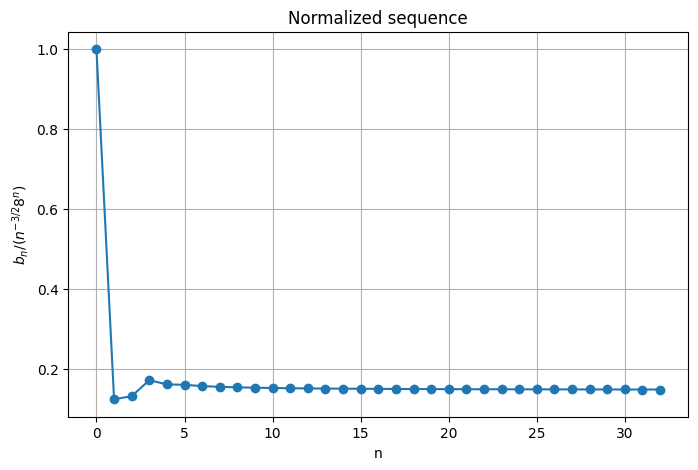

In [ ]:
import matplotlib.pyplot as plt

# sequence_b(20) is assumed to return [b_0, b_1, ..., b_N]
seq = testseq

norm_seq = []
for n, b_n in enumerate(seq):
    if n == 0:
        denom = 1
    else:
        denom = (n ** (-1.5)) * (8 ** n)
    norm_seq.append(b_n / denom)

print(norm_seq)

ns = list(range(len(seq)))

plt.figure(figsize=(8, 5))
plt.plot(ns, norm_seq, marker="o")
plt.xlabel("n")
plt.ylabel(r"$b_n / (n^{-3/2} 8^n)$")
plt.title(r"Normalized sequence")
plt.grid(True)
plt.show()

[1.0, 0.125, 0.14209842811034984, 0.1925630552568748, 0.1862147723920975, 0.189166431225369, 0.18865651641321823, 0.18951369395095674, 0.19046448414613443, 0.19156736959480888, 0.1927019851401054, 0.19383637522752625, 0.19495011222176814, 0.19603408635430192, 0.1970840784146844, 0.19809867225671393, 0.19907796611105494, 0.200022889116337, 0.20093480507637423, 0.20181528272360694, 0.20266596149215918, 0.20348847383746022, 0.20428440134829323, 0.20505525121643803, 0.20580244499887412, 0.20652731477484598, 0.20723110369280603, 0.2079149690495284, 0.2085799867483612, 0.20922715642162476, 0.20985740677716186, 0.21047160090292472, 0.21107054137385692]


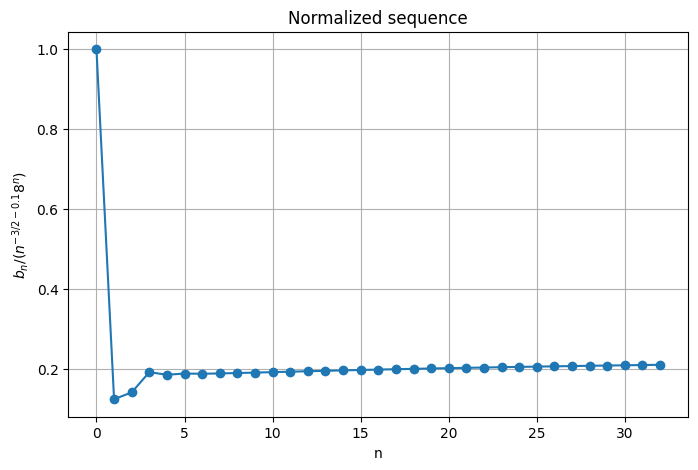

In [ ]:
import matplotlib.pyplot as plt

# sequence_b(20) is assumed to return [b_0, b_1, ..., b_N]
seq = testseq

norm_seq = []
for n, b_n in enumerate(seq):
    if n == 0:
        denom = 1
    else:
        denom = (n ** (-1.6)) * (8 ** n)
    norm_seq.append(b_n / denom)

print(norm_seq)

ns = list(range(len(seq)))

plt.figure(figsize=(8, 5))
plt.plot(ns, norm_seq, marker="o")
plt.xlabel("n")
plt.ylabel(r"$b_n / (n^{-3/2-0.1} 8^n)$")
plt.title(r"Normalized sequence")
plt.grid(True)
plt.show()

[1.0, 0.125, 0.12370386663495883, 0.15457836771422526, 0.1411244077218326, 0.13710398240263283, 0.1318382898025324, 0.12841654726000695, 0.12565969677605138, 0.12344486643183043, 0.12158673282006249, 0.11999322969199283, 0.11860069672380255, 0.11736616728378907, 0.11625882618384263, 0.11525593889281822, 0.1143402660939621, 0.1134984450434705, 0.11271991922733353, 0.11199621109886679, 0.11132041438324149, 0.11068683151277305, 0.11009070936253412, 0.10952804309233267, 0.10899542814447212, 0.10848994692499633, 0.1080090808854857, 0.10755064149008649, 0.10711271541739402, 0.10669362062672375, 0.1062918708115936, 0.10590614639634889, 0.10553527068692839]


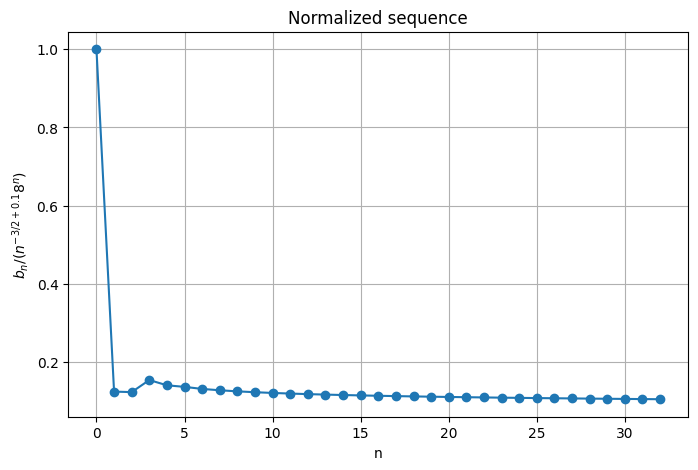

In [ ]:
import matplotlib.pyplot as plt

# sequence_b(20) is assumed to return [b_0, b_1, ..., b_N]
seq = testseq

norm_seq = []
for n, b_n in enumerate(seq):
    if n == 0:
        denom = 1
    else:
        denom = (n ** (-1.4)) * (8 ** n)
    norm_seq.append(b_n / denom)

print(norm_seq)

ns = list(range(len(seq)))

plt.figure(figsize=(8, 5))
plt.plot(ns, norm_seq, marker="o")
plt.xlabel("n")
plt.ylabel(r"$b_n / (n^{-3/2+0.1} 8^n)$")
plt.title(r"Normalized sequence")
plt.grid(True)
plt.show()